<a href="https://colab.research.google.com/github/ludenyobriannah-arch/python-face-verification/blob/main/Face_Verification_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       👤 FACE VERIFICATION SYSTEM

📸 Upload FIRST photo:


Saving WIN_20260922_18_25_00_Pro.jpg to WIN_20260922_18_25_00_Pro (3).jpg

✅ First photo uploaded!


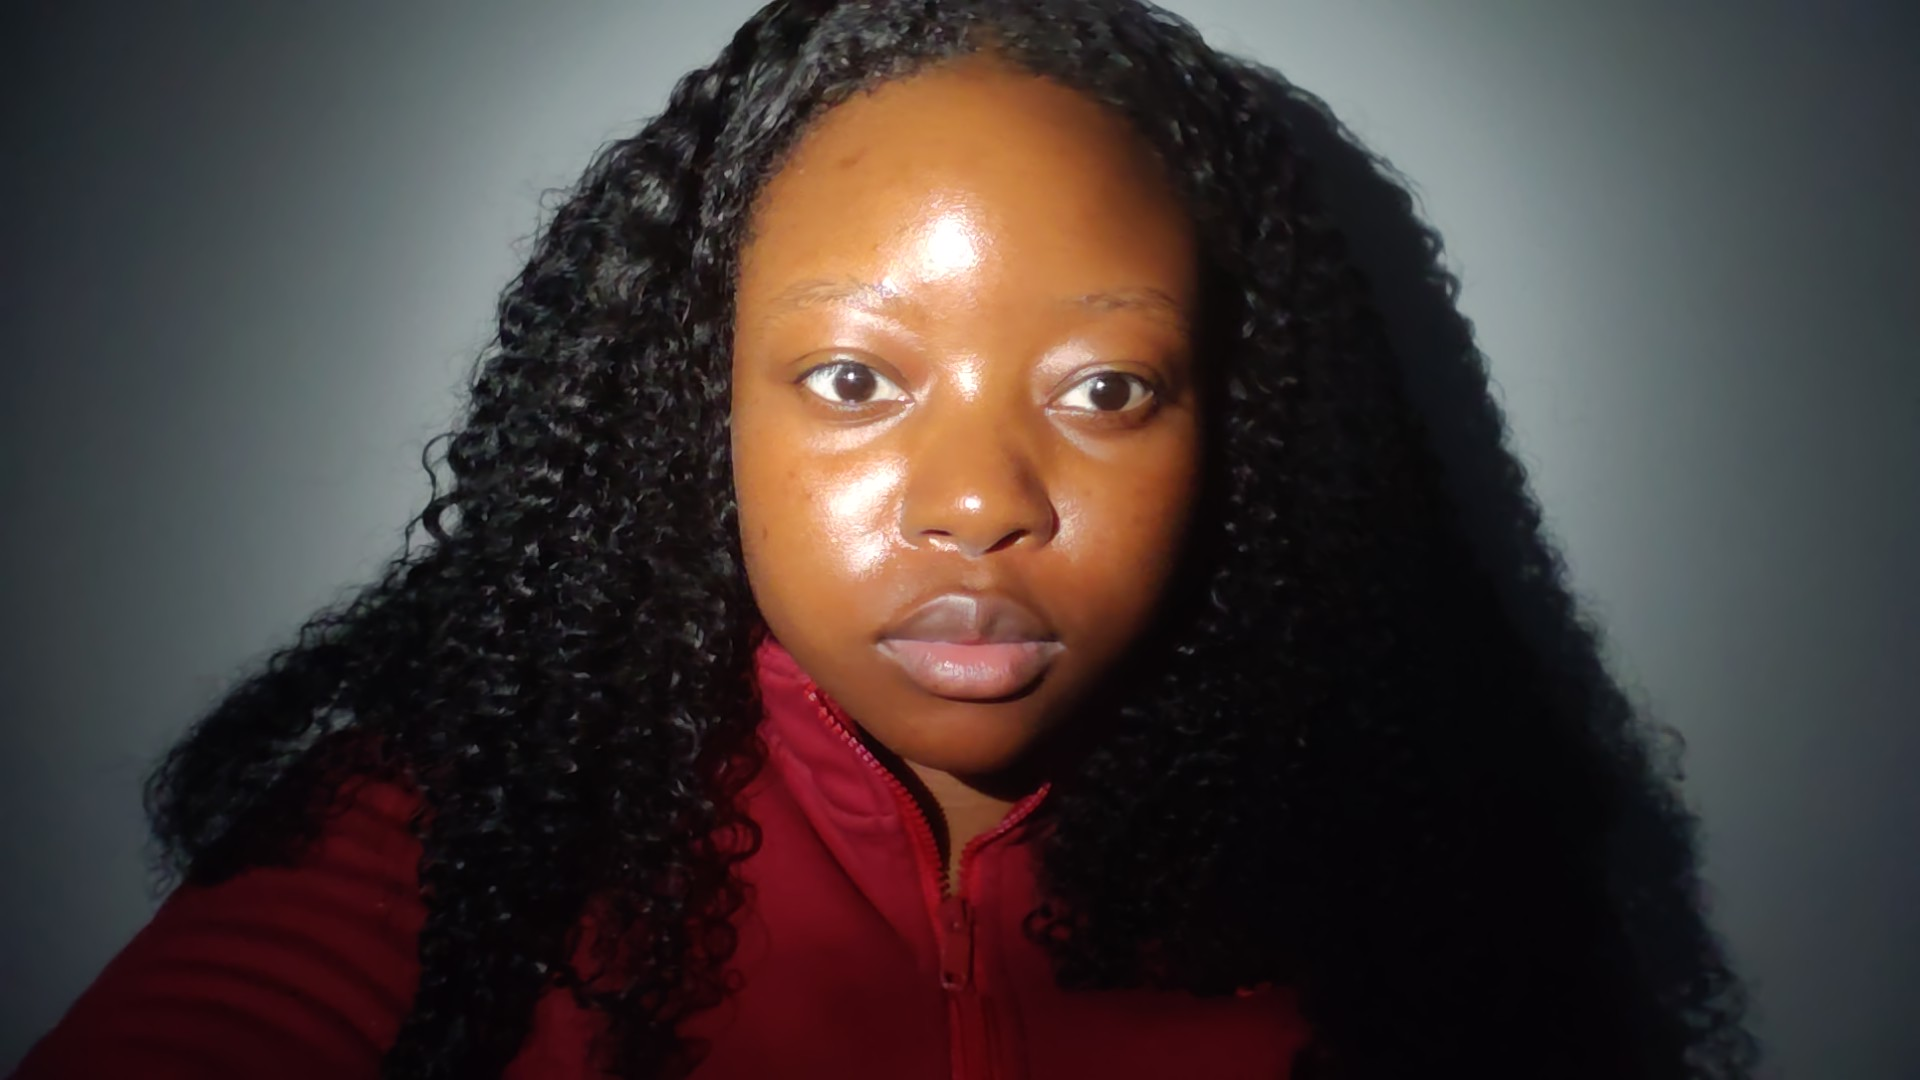


📸 Upload SECOND photo:


Saving WIN_20260922_18_25_33_Pro.jpg to WIN_20260922_18_25_33_Pro (1).jpg

✅ Second photo uploaded!


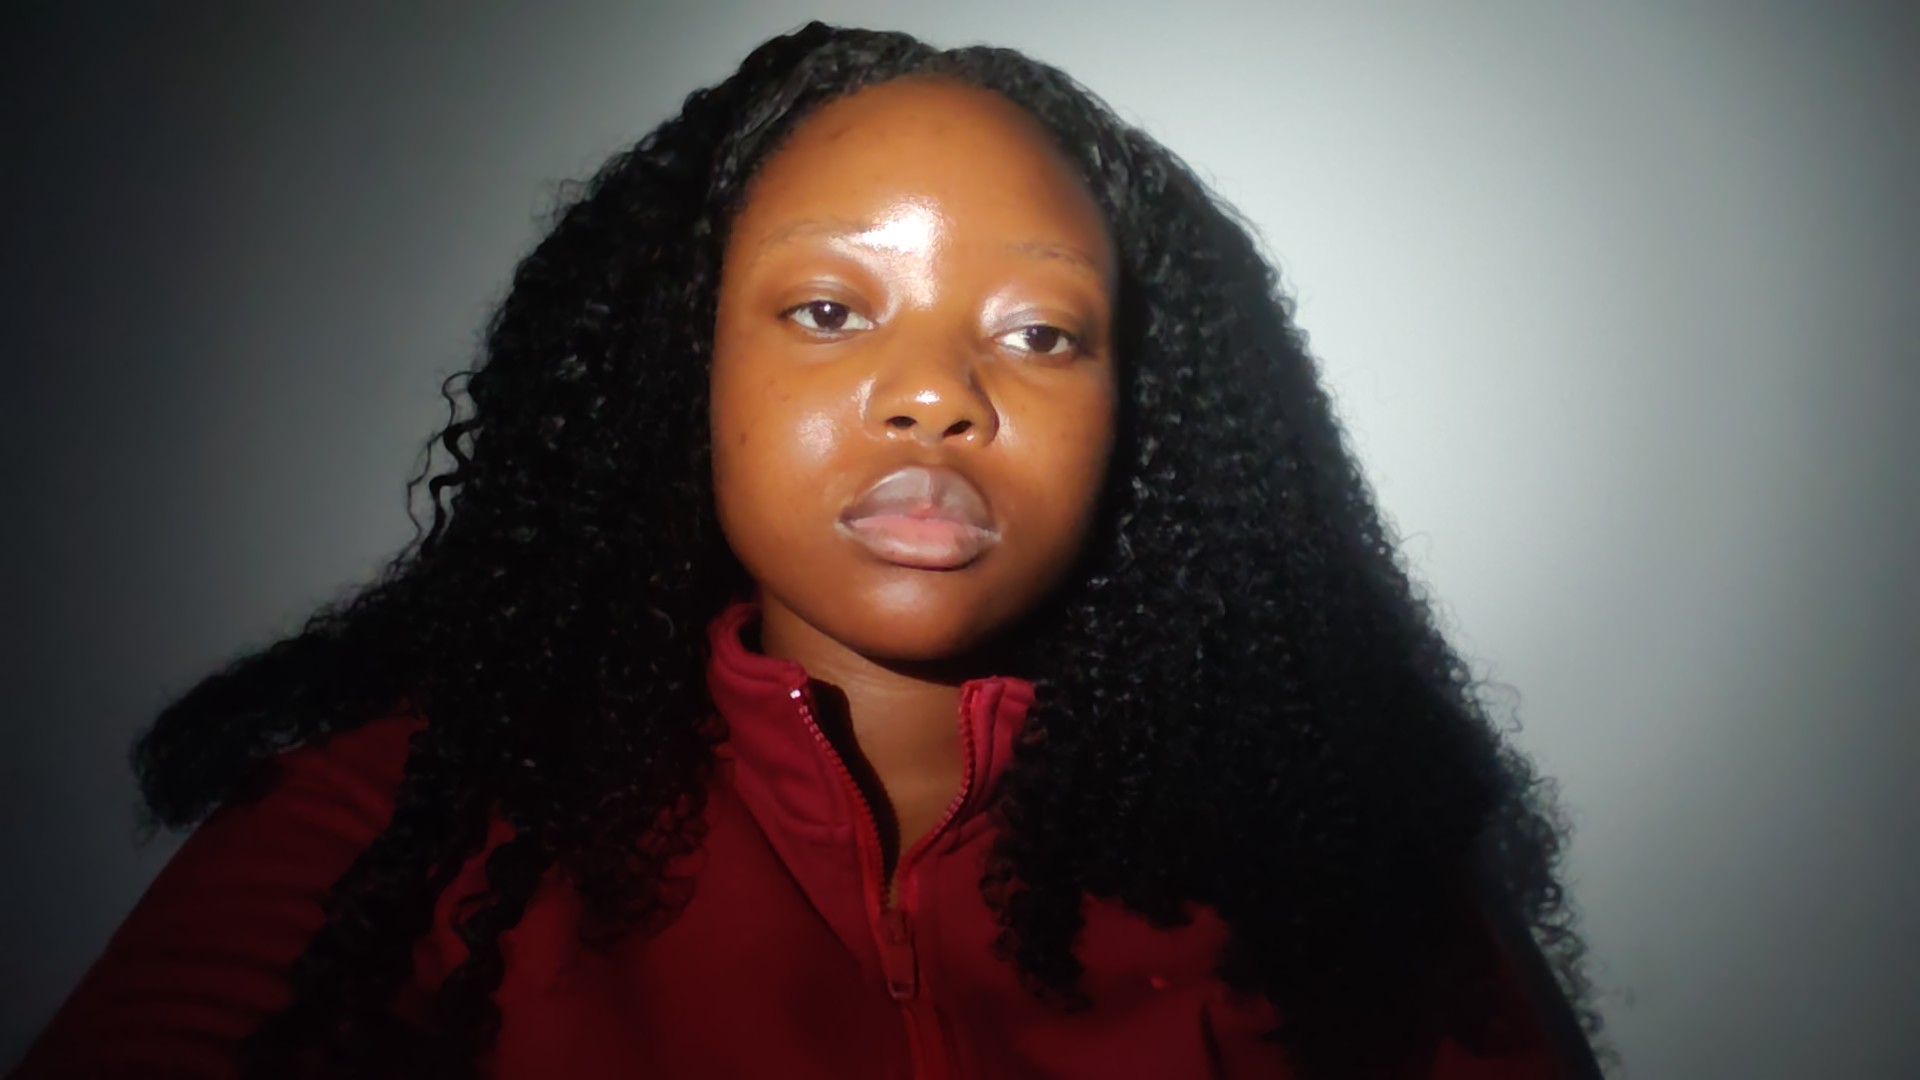


🔍 Analyzing faces...

✅ LIKELY MATCH
The faces are highly similar.

📊 FACE COMPARISON DETAILS
--------------------------------------
Distance: 0.2846
Match cutoff: 0.35
Review cutoff: 0.5
Model: ArcFace
Detector: RetinaFace

Distance guide:
Lower number = faces are more similar
Higher number = faces are less similar


In [4]:
# ============================================================
# FACE VERIFICATION PROJECT - IMPROVED VERSION
# ============================================================

!pip -q install deepface

from deepface import DeepFace
from google.colab import files
from IPython.display import display, Image

print("======================================")
print("       👤 FACE VERIFICATION SYSTEM")
print("======================================")

# ------------------------------------------------------------
# UPLOAD FIRST IMAGE
# ------------------------------------------------------------

print("\n📸 Upload FIRST photo:")
uploaded1 = files.upload()
image1 = list(uploaded1.keys())[0]

print("\n✅ First photo uploaded!")
display(Image(filename=image1, width=300))


# ------------------------------------------------------------
# UPLOAD SECOND IMAGE
# ------------------------------------------------------------

print("\n📸 Upload SECOND photo:")
uploaded2 = files.upload()
image2 = list(uploaded2.keys())[0]

print("\n✅ Second photo uploaded!")
display(Image(filename=image2, width=300))


# ------------------------------------------------------------
# COMPARE FACES
# ------------------------------------------------------------

print("\n🔍 Analyzing faces...")

try:

    result = DeepFace.verify(
        img1_path=image1,
        img2_path=image2,

        # ArcFace is another face-embedding model
        model_name="ArcFace",

        # RetinaFace finds/alines the face
        detector_backend="retinaface",

        # Cosine distance compares the embeddings
        distance_metric="cosine",

        enforce_detection=True
    )

    distance = result["distance"]

    # --------------------------------------------------------
    # DEMO THRESHOLDS
    #
    # Smaller distance = more similar.
    #
    # IMPORTANT:
    # These are deliberately conservative demo thresholds.
    # They should be validated on a larger set of your own
    # consented test photos before using this for anything real.
    # --------------------------------------------------------

    MATCH_THRESHOLD = 0.35
    REVIEW_THRESHOLD = 0.50

    print("\n======================================")

    if distance <= MATCH_THRESHOLD:

        print("✅ LIKELY MATCH")
        print("The faces are highly similar.")

    elif distance <= REVIEW_THRESHOLD:

        print("⚠️ UNCERTAIN")
        print("The result is too close to call reliably.")

    else:

        print("❌ LIKELY NOT A MATCH")
        print("The faces are not similar enough.")

    print("======================================")

    print("\n📊 FACE COMPARISON DETAILS")
    print("--------------------------------------")
    print("Distance:", round(distance, 4))
    print("Match cutoff:", MATCH_THRESHOLD)
    print("Review cutoff:", REVIEW_THRESHOLD)
    print("Model: ArcFace")
    print("Detector: RetinaFace")

    print("\nDistance guide:")
    print("Lower number = faces are more similar")
    print("Higher number = faces are less similar")

except Exception as error:

    print("\n❌ ERROR")
    print(error)

    print("\nMake sure:")
    print("• Each photo contains one clear face")
    print("• The face isn't heavily covered")
    print("• Lighting is reasonably good")
    print("• The face isn't extremely small")